# 04. Consumption Spike & Anomaly Detection

In this notebook we build a statistical anomaly detection system that identifies unusual consumption spikes and drops. We also categorize demand into Low, Medium, and High bands for operational use.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

## 4.1 Load Processed Data

In [2]:
df = pd.read_csv("../Dataset/processed/water_consumption_processed.csv")
df["date"] = pd.to_datetime(df["date"])
print(f"Loaded {len(df)} records")
df.head()

Loaded 865 records


,region,date,consumption_liters,day_of_week,is_weekend,month,day,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,Central,2023-01-08,15229.46,6,1,1,8,13596.90,14490.80,10624.100000,4925.797910
1,Central,2023-01-09,15022.47,0,0,1,9,15229.46,5916.42,10729.622857,5029.263310
2,Central,2023-01-10,12656.97,1,0,1,10,15022.47,18360.53,12030.487143,4746.521819
3,Central,2023-01-11,14112.66,2,0,1,11,12656.97,9499.28,11215.692857,3891.285699
4,Central,2023-01-12,14876.42,3,0,1,12,14112.66,5872.65,11874.747143,3942.471814


## 4.2 Z-Score Based Anomaly Detection
We compute a dynamic Z-score using a 7-day rolling window. Any point with |Z| > 2 is flagged as an anomaly.

In [3]:
threshold_std = 2.0

df["z_score"] = (df["consumption_liters"] - df["rolling_mean_7"]) / df["rolling_std_7"]
df["is_anomaly"] = (df["z_score"].abs() > threshold_std).astype(int)
df["anomaly_type"] = "Normal"
df.loc[(df["is_anomaly"] == 1) & (df["z_score"] > 0), "anomaly_type"] = "Spike"
df.loc[(df["is_anomaly"] == 1) & (df["z_score"] < 0), "anomaly_type"] = "Drop"

print("=== Anomaly Detection Results ===")
print(f"Total records analyzed: {len(df)}")
print(f"Anomalies detected: {df['is_anomaly'].sum()}")
print(f"\nBreakdown:")
print(df["anomaly_type"].value_counts())

=== Anomaly Detection Results ===
Total records analyzed: 865
Anomalies detected: 71

Breakdown:
anomaly_type
Normal    794
Drop       41
Spike      30
Name: count, dtype: int64


## 4.3 Anomalies Per Region

Anomalies by Region:


anomaly_type,Drop,Spike
region,,
Central,11,4
East,10,6
North,5,7
South,5,9
West,10,4


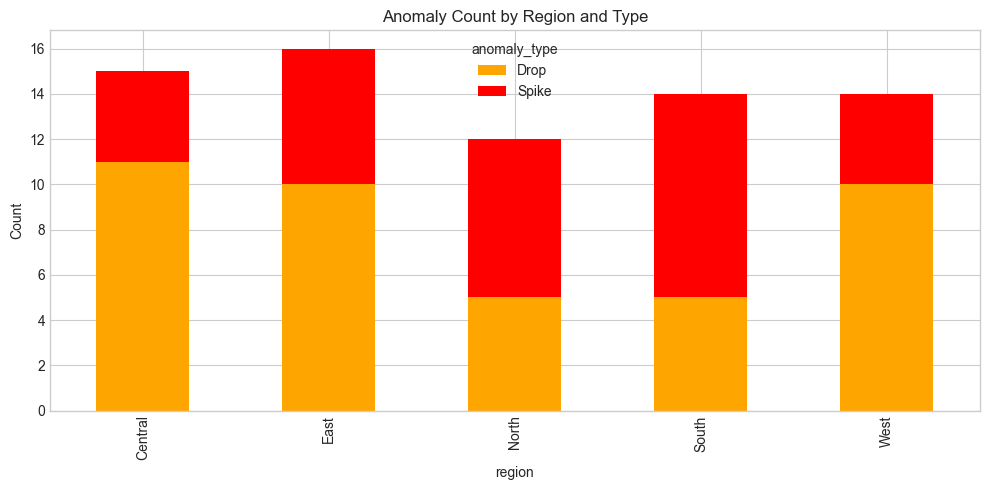

In [4]:
anomaly_by_region = df[df["is_anomaly"] == 1].groupby(["region", "anomaly_type"]).size().unstack(fill_value=0)
print("Anomalies by Region:")
display(anomaly_by_region)

anomaly_by_region.plot(kind="bar", stacked=True, figsize=(10, 5), color=["orange", "red"])
plt.title("Anomaly Count by Region and Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 4.4 Visualize Anomalies for Each Region

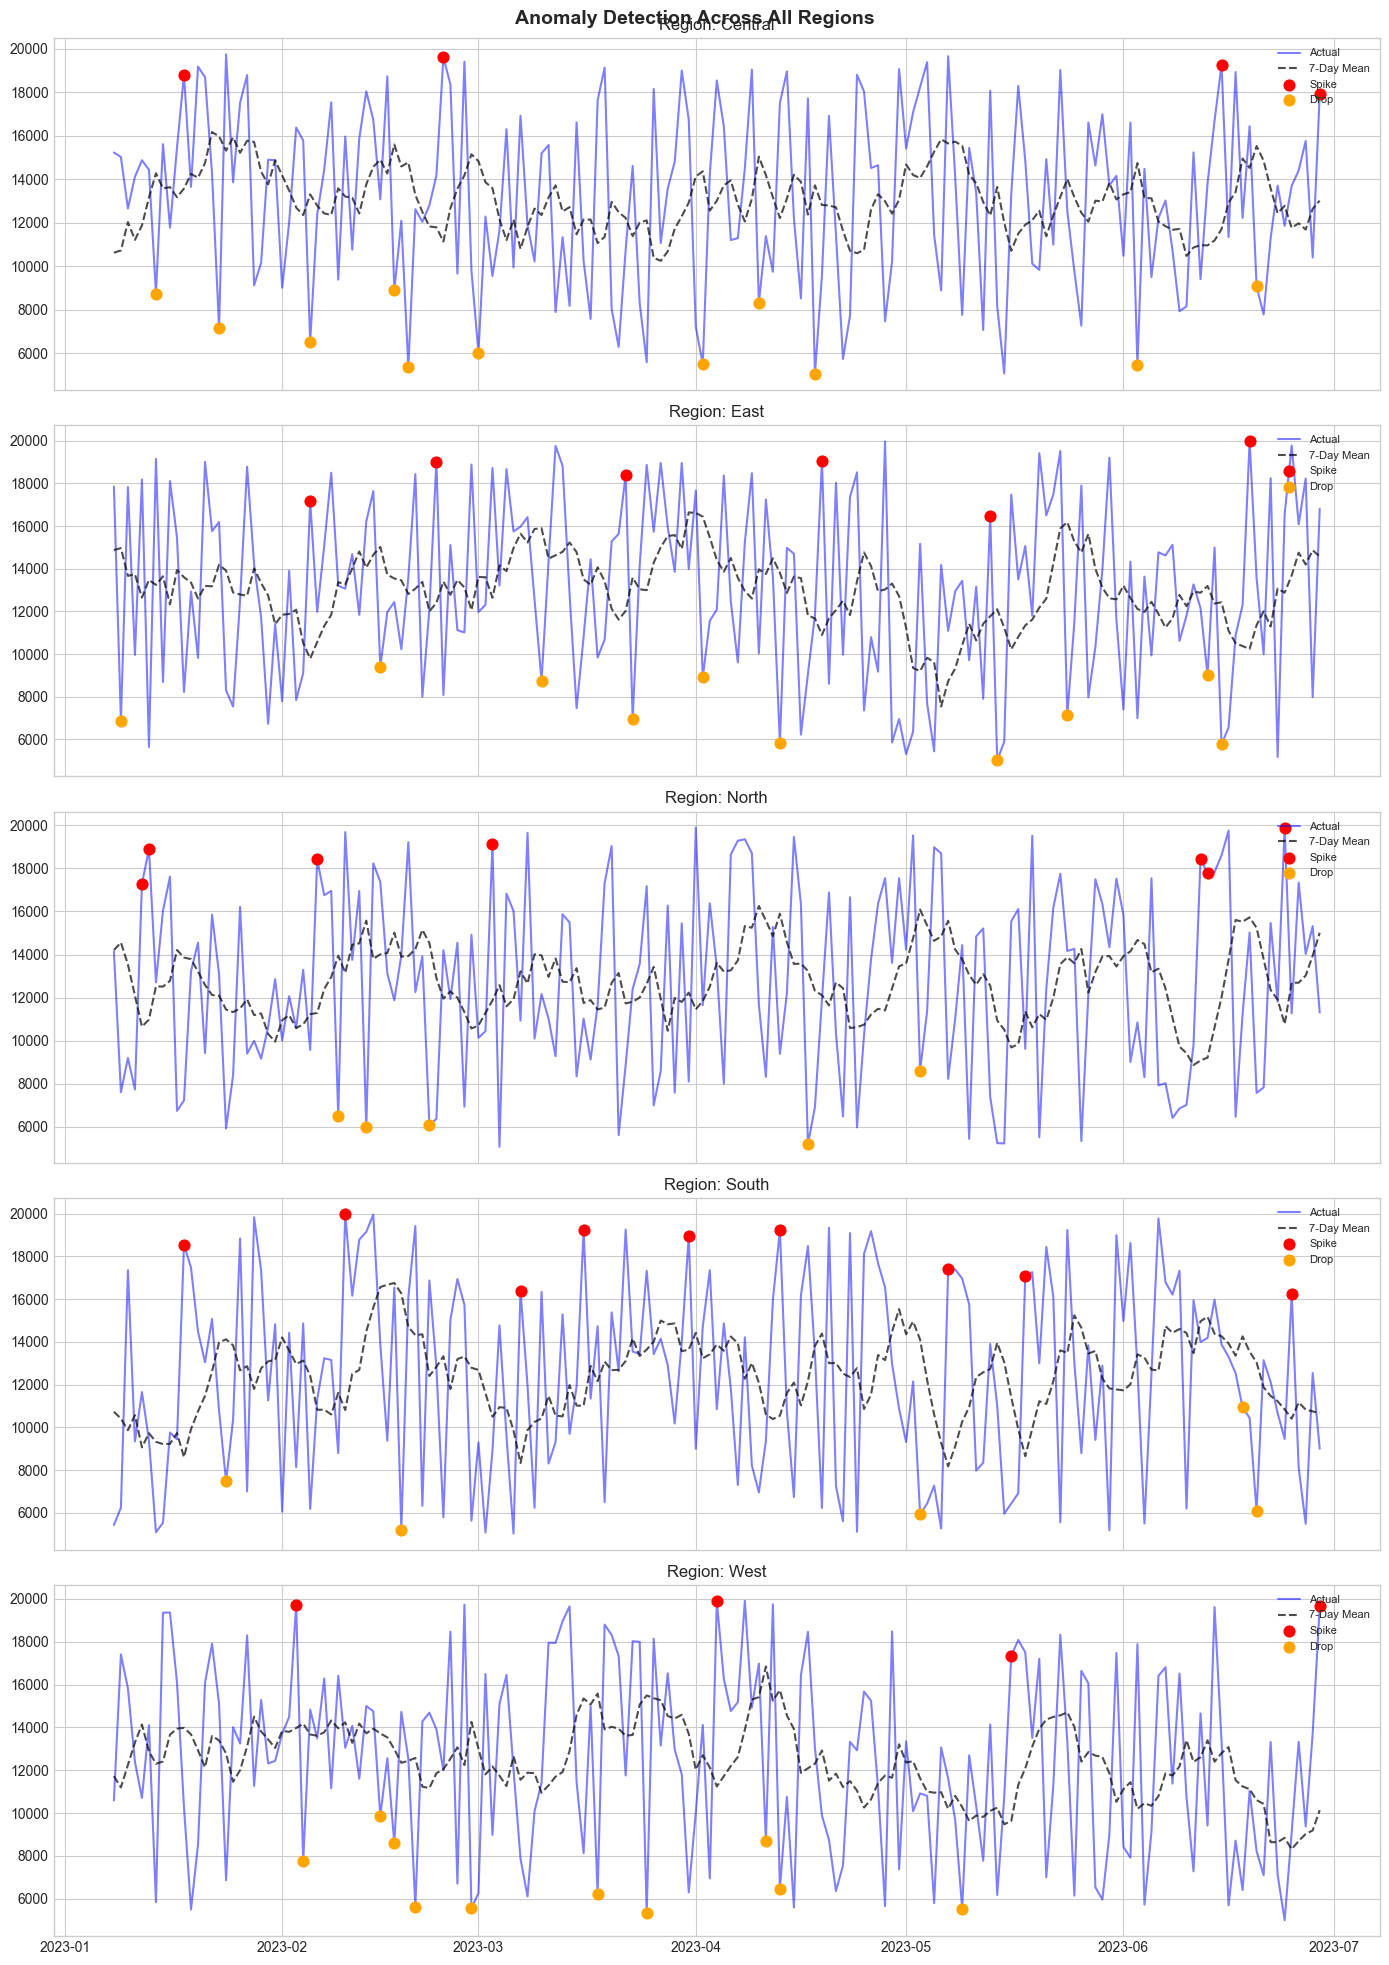

In [5]:
regions = df["region"].unique()
fig, axes = plt.subplots(len(regions), 1, figsize=(14, 4 * len(regions)), sharex=True)

for i, region in enumerate(regions):
    region_df = df[df["region"] == region]
    ax = axes[i]
    ax.plot(region_df["date"], region_df["consumption_liters"], color="blue", alpha=0.5, label="Actual")
    ax.plot(region_df["date"], region_df["rolling_mean_7"], color="black", linestyle="--", alpha=0.7, label="7-Day Mean")
    
    spikes = region_df[region_df["anomaly_type"] == "Spike"]
    drops = region_df[region_df["anomaly_type"] == "Drop"]
    ax.scatter(spikes["date"], spikes["consumption_liters"], color="red", s=60, zorder=5, label="Spike")
    ax.scatter(drops["date"], drops["consumption_liters"], color="orange", s=60, zorder=5, label="Drop")
    
    ax.set_title(f"Region: {region}")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Anomaly Detection Across All Regions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4.5 Z-Score Distribution

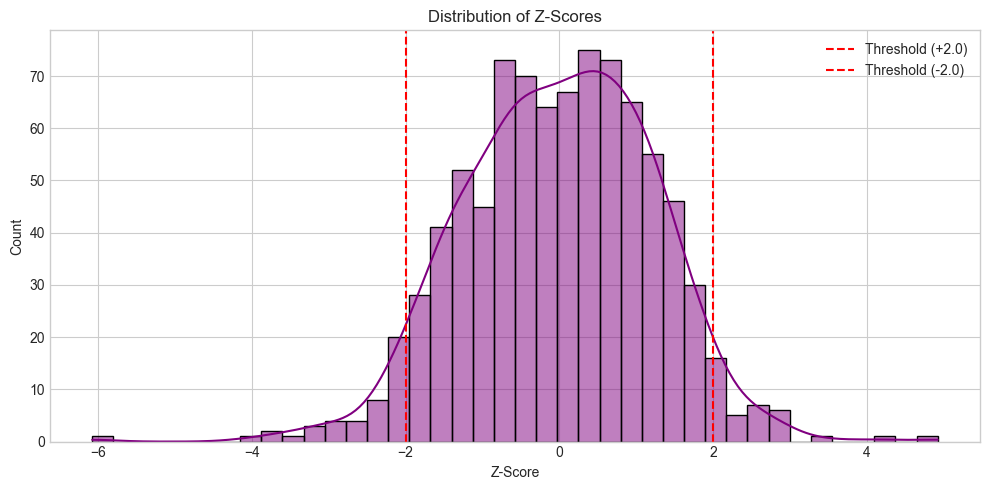

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df["z_score"].dropna(), bins=40, kde=True, color="purple")
plt.axvline(x=threshold_std, color="red", linestyle="--", label=f"Threshold (+{threshold_std})")
plt.axvline(x=-threshold_std, color="red", linestyle="--", label=f"Threshold (-{threshold_std})")
plt.title("Distribution of Z-Scores")
plt.xlabel("Z-Score")
plt.legend()
plt.tight_layout()
plt.show()

## 4.6 Demand Categorization
Categorizing consumption into Low, Medium, and High demand bands based on the 33rd and 67th percentiles.

Low threshold: 10584 Liters
High threshold: 15119 Liters

Demand Category Distribution:
demand_category
Medium    293
High      286
Low       286
Name: count, dtype: int64


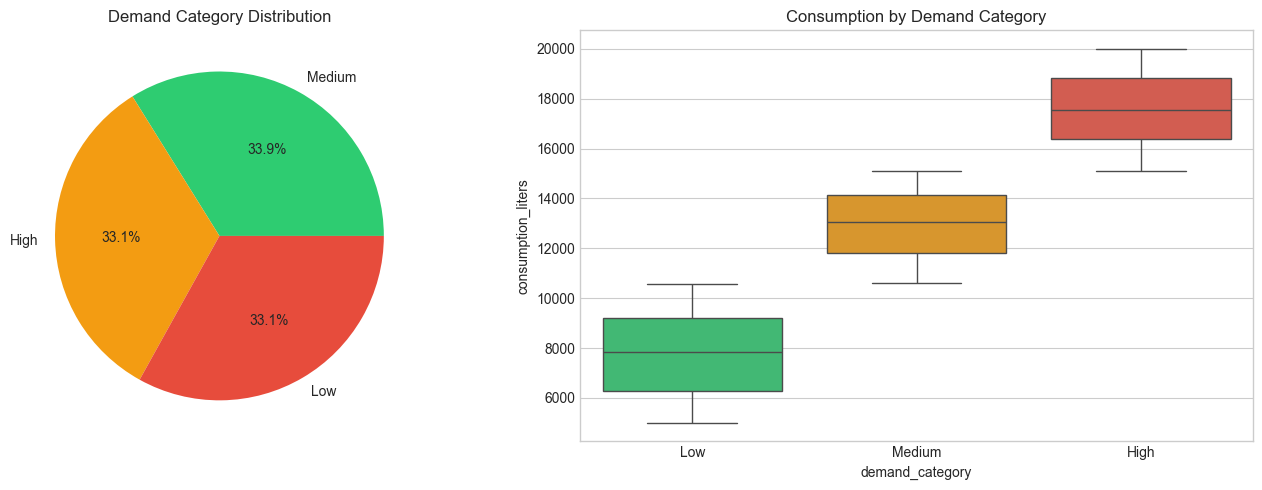

In [7]:
low_thresh = df["consumption_liters"].quantile(0.33)
high_thresh = df["consumption_liters"].quantile(0.67)

print(f"Low threshold: {low_thresh:.0f} Liters")
print(f"High threshold: {high_thresh:.0f} Liters")

def categorize(val):
    if val < low_thresh: return "Low"
    elif val > high_thresh: return "High"
    else: return "Medium"

df["demand_category"] = df["consumption_liters"].apply(categorize)

print("\nDemand Category Distribution:")
print(df["demand_category"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["demand_category"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["#2ecc71", "#f39c12", "#e74c3c"], ax=axes[0])
axes[0].set_title("Demand Category Distribution")
axes[0].set_ylabel("")

sns.boxplot(data=df, x="demand_category", y="consumption_liters", order=["Low", "Medium", "High"], palette=["#2ecc71", "#f39c12", "#e74c3c"], ax=axes[1])
axes[1].set_title("Consumption by Demand Category")

plt.tight_layout()
plt.show()

## 4.7 Summary of Anomaly Detection

| Metric | Value |
|---|---|
| Detection Method | Rolling Z-Score (7-day window) |
| Threshold | +/- 2.0 Standard Deviations |
| Total Anomalies | See above |
| Spike Events | Sudden surge in demand |
| Drop Events | Unexpected decrease in usage |

These anomaly labels and demand categories are used in the Streamlit dashboard for real-time early warning alerts.